In [1]:
# !pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),                 # Converts H×W×C [0,255] to C×H×W [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # Standard MNIST normalization[web:3]
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

len(train_dataset), len(test_dataset)

100%|██████████| 9.91M/9.91M [00:00<00:00, 80.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 32.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 96.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.92MB/s]


(60000, 10000)

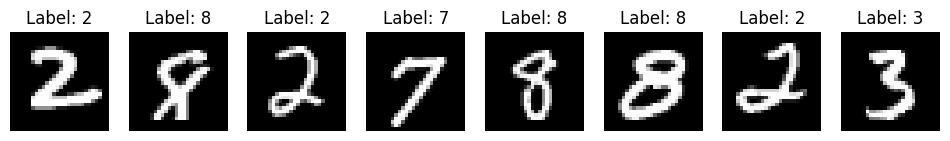

In [3]:
def show_batch(images, labels, n=8):
    images = images[:n]
    labels = labels[:n]
    images = images.squeeze(1).numpy()  # B×28×28

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap="gray")
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    plt.show()

images, labels = next(iter(train_loader))
show_batch(images, labels)


In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 1×28×28
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves H and W[web:7]
        self.dropout = nn.Dropout(0.25)

        # After two 2×2 pools: 28→14→7, so feature map is 32×7×7
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Block 1: conv → relu → pool
        x = self.pool(F.relu(self.conv1(x)))
        # Block 2: conv → relu → pool
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten
        x = x.view(x.size(0), -1)
        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # logits
        return x

model = SimpleCNN().to(device)
model


SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [7]:
num_epochs = 5

train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% "
          f"| Test Loss: {test_loss:.4f} | Test Acc: {test_acc*100:.2f}%")


Epoch [1/5] Train Loss: 0.2083 | Train Acc: 93.59% | Test Loss: 0.0556 | Test Acc: 98.15%
Epoch [2/5] Train Loss: 0.0691 | Train Acc: 97.92% | Test Loss: 0.0357 | Test Acc: 98.82%
Epoch [3/5] Train Loss: 0.0486 | Train Acc: 98.52% | Test Loss: 0.0329 | Test Acc: 98.85%
Epoch [4/5] Train Loss: 0.0393 | Train Acc: 98.74% | Test Loss: 0.0310 | Test Acc: 99.01%
Epoch [5/5] Train Loss: 0.0336 | Train Acc: 98.97% | Test Loss: 0.0279 | Test Acc: 99.11%


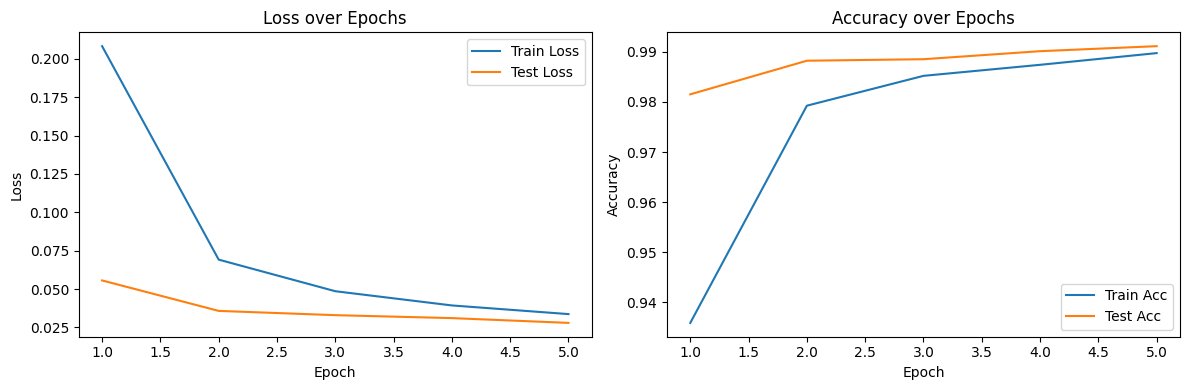

In [8]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Acc")
plt.plot(epochs, test_accs, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

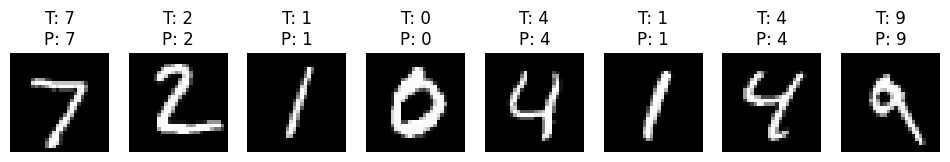

In [9]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images_cpu = images.cpu().squeeze(1).numpy()

n = 8
plt.figure(figsize=(12, 2))
for i in range(n):
    plt.subplot(1, n, i+1)
    plt.imshow(images_cpu[i], cmap="gray")
    plt.title(f"T: {labels[i].item()}\nP: {preds[i].item()}")
    plt.axis("off")
plt.show()

# **WHAT I LEARNED**


I learned how to use the MNIST dataset and convert images into tensors for training. I understood how a Convolutional Neural Network (CNN) works with layers like convolution, ReLU, and pooling to extract features from images. I learned how to build a CNN model in PyTorch, train it using a loss function and optimizer, and test it on new images. I also learned how to check the model’s accuracy and display predictions. Overall, I understood the complete process of creating, training, and evaluating a deep learning model for image classification.


A CNN works by looking at the image in small parts and finding patterns like lines and curves. The convolution layers detect these patterns, the ReLU makes learning faster, and the pooling layers reduce the image size to keep only important details. After that, all the features are combined and sent to fully connected layers, which decide which digit the image represents. In the end, the model gives the final prediction.the model predicts which digit (0–9) the image represents.

# **Possible** **Extensions**

 Augmentation Ready!
 SGD Ready!
 Dropout Example: tensor([[-0.3472,  0.0000, -0.0000, -0.8456, -2.2782, -0.9993, -0.1200,  2.1977,
         -1.2384,  1.2001]])


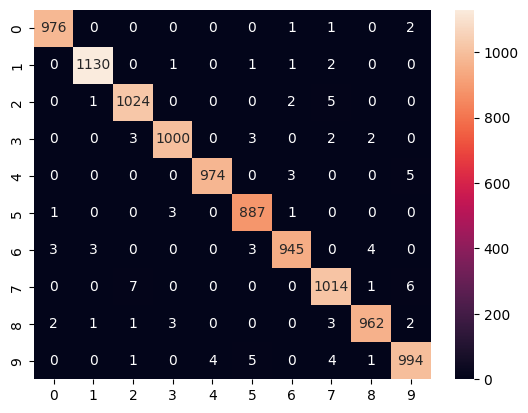

 Extra Training Done!


In [13]:
# ===== Possible Extensions =====

# 1️ Data Augmentation
from torchvision import transforms
aug_transform = transforms.Compose([transforms.RandomRotation(10),
                                    transforms.RandomAffine(0, translate=(0.1,0.1)),
                                    transforms.ToTensor()])
print(" Augmentation Ready!")

# 2️ Different Optimizer (SGD)
optimizer_sgd = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
print(" SGD Ready!")

# 3️ Dropout Example
import torch.nn as nn
dropout = nn.Dropout(0.3)
print(" Dropout Example:", dropout(torch.randn(1,10)))

# 4️ Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs)
        _, preds = torch.max(outputs,1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d")
plt.show()

# 5️ Extra Training Epochs
for _ in range(3):
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
print(" Extra Training Done!")


This code adds some extra steps to improve and check a CNN model. First, data augmentation changes images slightly by rotating or shifting them, which helps the model learn better. Then, a different optimizer (SGD) is used to update the model’s weights efficiently. A dropout example shows how some neurons are randomly turned off during training to prevent overfitting. The model is tested using a confusion matrix, which shows how many predictions were correct and where mistakes happened. Finally, the model is trained for a few extra epochs to make it even more accurate. Overall, these steps make the model stronger and easier to evaluate.